In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import rv_continuous

In [3]:
PDF_X = np.linspace(0, 200, 1000)
trapezoid = np.trapz

In [4]:
class AsymmetricGaussian(rv_continuous):
    """
    Custom Asymmetric Gaussian distribution.
    Use loc for the mean, and unc_minus/unc_plus as shape parameters.
    """
    def _pdf(self, x, unc_minus, unc_plus):
        """x is already shifted by loc internally by scipy"""
        pdf = np.where(
            x < 0,
            np.exp(-0.5 * (x / unc_minus)**2),
            np.exp(-0.5 * (x / unc_plus)**2)
        )
        
        norm = np.sqrt(2 / (np.pi * (unc_plus + unc_minus)**2))
        return norm * pdf

    def _rvs(self, unc_minus, unc_plus, size=None, random_state=None):
        """Generate random samples from the asymmetric Gaussian"""
        rng = np.random.default_rng()
        # To match _pdf, each side must carry mass unc/(unc_minus + unc_plus),
        # not 50/50: pick the side first, then draw a half-normal on that side
        left = rng.random(size) < unc_minus / (unc_minus + unc_plus)
        half = np.abs(rng.standard_normal(size))
        samples = np.where(left, -half * unc_minus, half * unc_plus)
        return samples

ag = AsymmetricGaussian()

In [5]:
base_loc = 100
base_std = 5
base_pdf = ag.pdf(PDF_X, loc=base_loc, unc_minus=base_std, unc_plus=base_std)

test_pdfs = dict(
    base_pdf = dict(loc=100,unc_minus=5, unc_plus=5),
    deltafunc_pdf = dict(loc=100, unc_minus=1, unc_plus=1),
    deltafunc_slightly_offset_pdf = dict(loc=105, unc_minus=1, unc_plus=1),
    deltafunc_offset_pdf = dict(loc=150, unc_minus=1, unc_plus=1),
    wide_pdf = dict(loc=100,unc_minus=10, unc_plus=10),
    wide_slightly_offset_pdf = dict(loc=105, unc_minus=10, unc_plus=10),
    wide_pdf_offset = dict(loc=115, unc_minus=10, unc_plus=10),
    wide_pdf_veryoffset = dict(loc=150,unc_minus=10, unc_plus=10),
    verywide_pdf = dict(loc=100,unc_minus=50, unc_plus=50),
    verywide_slightly_offset_pdf = dict(loc=105,unc_minus=50, unc_plus=50),
    verywide_pdf_offset = dict(loc=150,unc_minus=50, unc_plus=50),
    asymmetric_pdf_deltafunc = dict(loc=100, unc_minus=0.5, unc_plus=1),
    asymmetric_pdf_deltafunc_offset = dict(loc=150, unc_minus=0.5, unc_plus=1),
    asymmetric_pdf_wide = dict(loc=100, unc_minus=7.5, unc_plus=12.5),
    asymmetric_pdf_wide_offset = dict(loc=150, unc_minus=7.5, unc_plus=12.5),
    asymmetric_pdf_wide_offset_neg = dict(loc=50, unc_minus=7.5, unc_plus=12.5),
    asymmetric_pdf_very_skewed = dict(loc=100, unc_minus=50, unc_plus=1),
    asymmetric_pdf_very_skewed_offset = dict(loc=120, unc_minus=50, unc_plus=1),
    asymmetric_pdf_very_skewed_very_offset_pos = dict(loc=180, unc_minus=50, unc_plus=1),
    asymmetric_pdf_very_skewed_very_offset_neg = dict(loc=(100-80), unc_minus=50, unc_plus=1),
    asymmetric_pdf_very_skewed_slightly_offset_neg = dict(loc=95, unc_minus=50, unc_plus=1),
    asymmetric_pdf_very_skewed_moderately_offset_neg = dict(loc=92, unc_minus=50, unc_plus=1),
    asymmetric_v4_straddle = dict(loc=94, unc_minus=1, unc_plus=15),
)

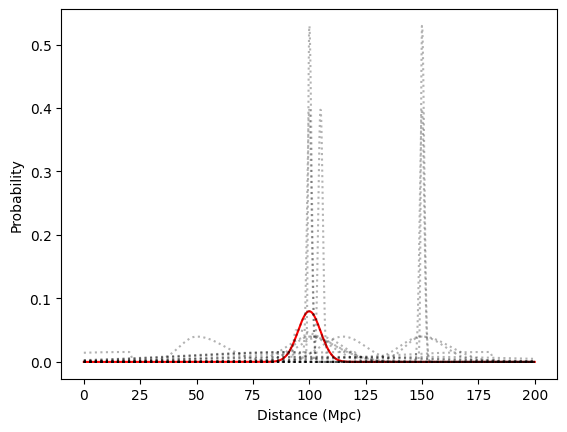

In [6]:
fig, ax = plt.subplots()

ax.plot(PDF_X, base_pdf, color="r")

for label, test_params in test_pdfs.items():
    test = ag.pdf(PDF_X, **test_params)
    ax.plot(PDF_X, test, color="k", alpha=0.3, linestyle=":")
    ax.set_xlabel('Distance (Mpc)')
    ax.set_ylabel('Probability')

In [7]:
from scipy.special import erf, erfc

def normalization_prefactor(mean_gw, sigma_gw, mean_cand, sigma_cand_neg, sigma_cand_pos):
    prefactor_cand = np.sqrt(2/np.pi) * (sigma_cand_pos + sigma_cand_neg*erf(mean_cand/(sigma_cand_neg*np.sqrt(2))))**-1
    prefactor_gw = float(sigma_gw)**-1 * np.sqrt(2/np.pi) * (1 + erf(mean_gw/(sigma_gw*np.sqrt(2))))**-1
    return np.sqrt(prefactor_cand*prefactor_gw)

def a(sigma_gw, sigma_cand):
    return 1/sigma_gw**2 + 1/sigma_cand**2
        
def b(mean_gw, sigma_gw, mean_cand, sigma_cand):
    return mean_gw/sigma_gw**2 + mean_cand/sigma_cand**2

def c(mean_gw, sigma_gw, mean_cand, sigma_cand):
    return (mean_gw/sigma_gw)**2 + (mean_cand/sigma_cand)**2

def p(_a, _b, _c):
    return np.sqrt(np.pi/_a) * np.exp(-0.25*(_c - _b**2/_a))

# Re-think this bc_integral combination
def bc_integral_neg(mean_gw, sigma_gw, mean_cand, sigma_cand_neg):
    _a = a(sigma_gw, sigma_cand_neg)
    _b = b(mean_gw, sigma_gw, mean_cand, sigma_cand_neg)
    _c = c(mean_gw, sigma_gw, mean_cand, sigma_cand_neg)

    _p = p(_a, _b, _c)
    x0 = erf(-_b/(2*np.sqrt(_a)))
    x1 = erf(np.sqrt(_a)/2 * (mean_cand - _b/_a))
    return _p*(x1-x0)

def bc_integral_pos(mean_gw, sigma_gw, mean_cand, sigma_cand_pos):
    _a = a(sigma_gw, sigma_cand_pos)
    _b = b(mean_gw, sigma_gw, mean_cand, sigma_cand_pos)
    _c = c(mean_gw, sigma_gw, mean_cand, sigma_cand_pos)

    _p = p(_a, _b, _c)
    return _p*erfc(np.sqrt(_a)/2 * (mean_cand - _b/_a))

def bc(mean_gw, sigma_gw, mean_cand, sigma_cand_neg, sigma_cand_pos):
    lower_args = (mean_gw, sigma_gw, mean_cand, sigma_cand_neg)
    upper_args = (mean_gw, sigma_gw, mean_cand, sigma_cand_pos)
    norm = normalization_prefactor(mean_gw, sigma_gw, mean_cand, sigma_cand_neg, sigma_cand_pos)
    # Shouldn't this be averaged, not naively summed?
    return norm*(bc_integral_neg(*lower_args) + bc_integral_pos(*upper_args))

# TODO: What is the impact of this k parameter in the distance scoring? 
def sigmoid(x, k=1):
    return 1 / (1 + np.exp(-k * x))

def smooth_tophat(x, a, b, k=1):
    return sigmoid(x - a, k) * (1 - sigmoid(x - b, k))

# n_sigma is the range that is considered right now
def smooth_tophat_score(galaxy_dist, gw_mean, gw_std, nsigma=2):
    return smooth_tophat(galaxy_dist, gw_mean-nsigma*gw_std, gw_mean+nsigma*gw_std)

def tophat_score(galaxy_dist, gw_mean, gw_std, nsigma=2,
                 cliff=2.5,            # sigma where the steep drop happens
                 cliff_steepness=4,    # super-Gaussian order; higher = flatter top, sharper cliff
                 box_edge_score=0.95,  # target score at +/- nsigma (sets the in-box gradient)
                 tail_scale=6.0):      # sigma-scale of the heavy tail
    z = (galaxy_dist - gw_mean) / gw_std
    u = np.abs(z)
    alpha = np.log(box_edge_score) / nsigma**2
    tilt = np.exp(alpha * u**2)        # (A) gentle in-box gradient
    core = np.exp(-(u / cliff)**(2 * cliff_steepness)) # (B) flat plateau + steep cliff
    tail = 1.0 / (1.0 + (u / tail_scale)**2)           # (C) heavy tail
    # Find where this value gives desirable results
    weight = 0.98
    return (weight) * tilt * core + (1 - weight) * tail

def sigma_ratio(gw_std, sigma_minus, sigma_plus):
    # original: naive unweighted average of the two tails
    return np.mean([sigma_minus, sigma_plus], axis=0) / gw_std

def weight_linear(r):
    return np.minimum(1.0, r)                                   # original behaviour

def weight_hill(r, n=2, r_half=1.0):
    # Smooth saturating ramp, no kink: w=0.5 at r=r_half, -> 1 as r grows.
    return r**n / (r**n + r_half**n)

# Justify a scale value physically or intuitively
def weight_tanh(r, scale=1.0):
    return np.tanh(r / scale)

# Mess around with the logistic k parameter
# Must have some physical reasoning for why the k-value is chosen
def weight_logistic(r, r0=1.0, k=4.0):
    # Soft threshold: stays ~0 (trust top-hat) until r ~ r0, then switches on.
    return 1.0 / (1.0 + np.exp(-k * (r - r0)))

def hybrid(gw_mean, galaxy_mean, gw_std, galaxy_std_minus, galaxy_std_plus, verbose=True):

    if galaxy_std_minus == 0 or galaxy_std_plus == 0:
        bc_score = 0 # this score should be computed in the sigmoid regime
    else:
        bc_score = bc(gw_mean, gw_std, galaxy_mean, galaxy_std_minus, galaxy_std_plus)

    ts = smooth_tophat_score(galaxy_mean, gw_mean, gw_std)

    # What is the reason why this specifically and not gw_std**2 or something non-linear with the uncertainties?
    # this weight will be small for spec-z's and large for photo-z's   
    w = np.mean([galaxy_std_minus, galaxy_std_plus], axis=0) / gw_std
    max_w = np.ones(w.shape)
    w = np.min([max_w, w], axis=0)

    if verbose:
        print(f"\tBC={bc_score}", f"S={ts}", f"w={w}", f"score={(1-w)*ts + w*bc_score}")

    return np.clip((1-w)*ts + w*bc_score, 0, 1)

# Logistic Weighting is generally producing better results, so further tests will use logistic weighting
def hybrid_v2(gw_mean, galaxy_mean, gw_std, galaxy_std_minus, galaxy_std_plus,
              weight_fn=weight_logistic, verbose=True):
    if galaxy_std_minus == 0 or galaxy_std_plus == 0:
        bc_score = 0 # this score should be computed in the sigmoid regime
    else:
        bc_score = bc(gw_mean, gw_std, galaxy_mean, galaxy_std_minus, galaxy_std_plus)

    ts = smooth_tophat_score(galaxy_mean, gw_mean, gw_std)

    # sigma combination: naive unweighted average of the two tails
    r = sigma_ratio(gw_std, galaxy_std_minus, galaxy_std_plus)
    w = np.clip(weight_fn(r), 0.0, 1.0)

    # Bhattacharya Coefficient is good (Potentially work on this a bit though)
    # Non-linear weighting and tophat scoring needs improvement
    if verbose:
        print(f"\tBC={bc_score}", f"S={ts}", f"w={w}", f"score={(1-w)*ts + w*bc_score}")

    return np.clip((1-w)*ts + w*bc_score, 0, 1)

# Key improvements are higher scores for delta_functions closer to the mean
def hybrid_v3(gw_mean, galaxy_mean, gw_std, galaxy_std_minus, galaxy_std_plus,
              weight_fn=weight_logistic, verbose=True):
    if galaxy_std_minus == 0 or galaxy_std_plus == 0:
        bc_score = 0 # this score should be computed in the sigmoid regime
    else:
        bc_score = bc(gw_mean, gw_std, galaxy_mean, galaxy_std_minus, galaxy_std_plus)

    ts = tophat_score(galaxy_mean, gw_mean, gw_std)

    # sigma combination: naive unweighted average of the two tails
    r = sigma_ratio(gw_std, galaxy_std_minus, galaxy_std_plus)
    w = np.clip(weight_fn(r), 0.0, 1.0)

    # Bhattacharya Coefficient is good (Potentially work on this a bit though)
    # Non-linear weighting and tophat scoring needs improvement
    if verbose:
        print(f"\tBC={bc_score}", f"S={ts}", f"w={w}", f"score={(1-w)*ts + w*bc_score}")

    return np.clip((1-w)*ts + w*bc_score, 0, 1)

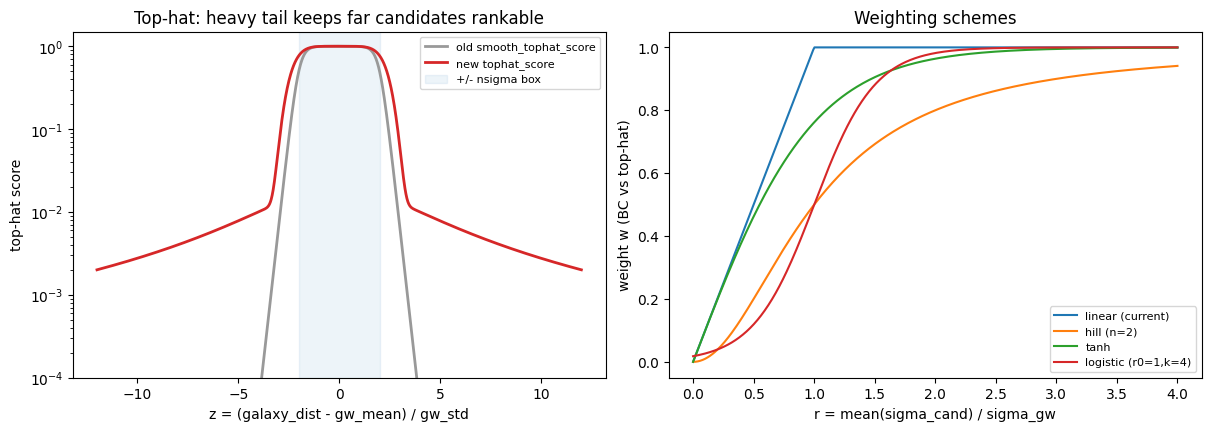

In [17]:
# ==========================================================================
# Diagnostics: hybrid (old top-hat) vs hybrid_v2 (new top-hat), and the
# effect of the different weighting schemes. All quiet (verbose=False).
# ==========================================================================
import os
os.makedirs("hybrid_new/diagnostics", exist_ok=True)

# # ---- 1. score table: hybrid vs hybrid_v2 + difference -------------------
# print(f"{'test':<48}{'hybrid':>9}{'hybrid_v2':>11}{'diff':>10}{'w':>7}")
# print("-" * 85)
# for label, t in test_pdfs.items():
#     h = hybrid(base_loc, t['loc'], base_std, t['unc_minus'], t['unc_plus'], verbose=False)
#     v = hybrid_v2(base_loc, t['loc'], base_std, t['unc_minus'], t['unc_plus'], verbose=False)
#     w = float(weight_linear(base_std, t['unc_minus'], t['unc_plus']))
#     print(f"{label:<48}{float(h):>9.5f}{float(v):>11.5f}{float(h - v):>+10.5f}{w:>7.2f}")

# # ---- 2. weighting-scheme comparison on representative cases --------------
# schemes = {'linear': weight_linear, 'hill': weight_hill,
#            'tanh': weight_tanh, 'logistic': weight_logistic}
# print(f"\n{'test':<40}{'r':>6}" + "".join(f"{s:>10}" for s in schemes))
# for label in ['deltafunc_pdf', 'deltafunc_slightly_offset_pdf', 'asymmetric_pdf_deltafunc',
#               'wide_pdf', 'wide_slightly_offset_pdf', 'verywide_pdf', 'asymmetric_v4_straddle']:
#     t = test_pdfs[label]
#     r = float(weight_linear(base_std, t['unc_minus'], t['unc_plus']))  # note: linear is clipped
#     r_raw = (t['unc_minus'] + t['unc_plus']) / 2 / base_std
#     row = [float(hybrid_v2(base_loc, t['loc'], base_std, t['unc_minus'], t['unc_plus'],
#                            weight_fn=wf, verbose=False)) for wf in schemes.values()]
#     print(f"{label:<40}{r_raw:>6.2f}" + "".join(f"{x:>10.4f}" for x in row))

# ---- 3. plot the top-hats and the weighting curves ----------------------
z = np.linspace(-12, 12, 2000)
dist = base_loc + z * base_std

fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4.2), constrained_layout=True)

axL.plot(z, [smooth_tophat_score(d, base_loc, base_std) for d in dist],
         label="old smooth_tophat_score", color="0.6", lw=2)
axL.plot(z, [tophat_score(d, base_loc, base_std, box_edge_score=1.0, cliff=2.5, cliff_steepness=3, tail_scale=4) for d in dist],
         label="new tophat_score", color="C3", lw=2)
axL.axvspan(-2, 2, color="C0", alpha=0.08, label="+/- nsigma box")
axL.set_xlabel("z = (galaxy_dist - gw_mean) / gw_std")
axL.set_ylabel("top-hat score")
axL.set_yscale("log")
axL.set_ylim(1e-4, 1.5)
axL.set_title("Top-hat: heavy tail keeps far candidates rankable")
axL.legend(fontsize=8)

r = np.linspace(0, 4, 400)
sig = base_std
axR.plot(r, [float(weight_linear(ri)) for ri in r], label="linear (current)")
axR.plot(r, [float(weight_hill(ri)) for ri in r], label="hill (n=2)")
axR.plot(r, [float(weight_tanh(ri)) for ri in r], label="tanh")
axR.plot(r, [float(weight_logistic(ri)) for ri in r], label="logistic (r0=1,k=4)")
axR.set_xlabel("r = mean(sigma_cand) / sigma_gw")
axR.set_ylabel("weight w (BC vs top-hat)")
axR.set_title("Weighting schemes")
axR.legend(fontsize=8)

fig.savefig("hybrid_new/diagnostics/tophat_and_weighting.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
def hybrid_v4(gw_mean, galaxy_mean, gw_std, galaxy_std_minus, galaxy_std_plus,
              weight_fn=weight_logistic, verbose=True):
    if galaxy_std_minus == 0 or galaxy_std_plus == 0:
        bc_score = 0 # this score should be computed in the sigmoid regime
    else:
        bc_score = bc(gw_mean, gw_std, galaxy_mean, galaxy_std_minus, galaxy_std_plus)

    ts = tophat_score(galaxy_mean, gw_mean, gw_std, box_edge_score=1.0, cliff=2.5, cliff_steepness=3, tail_scale=4)

    # old sigma combination: naive unweighted average
    r = sigma_ratio(gw_std, galaxy_std_minus, galaxy_std_plus)
    w = np.clip(weight_fn(r), 0.0, 1.0)

    # Bhattacharya Coefficient is good (Potentially work on this a bit though)
    # Non-linear weighting and tophat scoring needs improvement
    if verbose:
        print(f"\tBC={bc_score}", f"S={ts}", f"w={w}", f"score={(1-w)*ts + w*bc_score}")

    return np.clip((1-w)*ts + w*bc_score, 0, 1)

# v3 is the original tophat, whereas v4 is the new tophat with slightly different parameters
v4 = []

ncols = 4
nrows = int(np.ceil(len(test_pdfs) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.5*ncols, 3.2*nrows), constrained_layout=True)

base_pdf_norm = base_pdf / np.sum(base_pdf)

for ax, (label, test) in zip(axes.flat, test_pdfs.items()):
    print(label)
    test_pdf = ag.pdf(PDF_X, **test)
    test_pdf = test_pdf / np.sum(test_pdf)

    final_score = hybrid_v4(base_loc, test['loc'], base_std, test['unc_minus'], test['unc_plus'], verbose=True)
    v4.append(final_score)

    ax.plot(PDF_X, base_pdf_norm, color="r", label="Sample GW PDF", alpha=0.5)
    ax.plot(PDF_X, test_pdf, color="k", label="Sample Host PDF", alpha=0.5)
    ax.set_title(f"{label}\nFinal Score: {float(final_score):.4g}", fontsize=8)

# hide any unused grid slots
for ax in axes.flat[len(test_pdfs):]:
    ax.axis("off")

axes.flat[0].legend(fontsize=7)
fig.suptitle("v4", fontsize=18)
fig.savefig("hybrid_new/v4.png", dpi=150, bbox_inches="tight")
plt.close(fig)

base_pdf
	BC=1.0000000000000002 S=1.0 w=0.5 score=1.0
deltafunc_pdf
	BC=0.6201736729460423 S=1.0 w=0.039165722796764356 score=0.9851238273636915
deltafunc_slightly_offset_pdf
	BC=0.48765829288336193 S=0.9948176590349076 w=0.039165722796764356 score=0.9749543958864334
deltafunc_offset_pdf
	BC=2.252901096617221e-11 S=0.002758620689655175 w=0.039165722796764356 score=0.002650577317305086
wide_pdf
	BC=0.894427190999916 S=1.0 w=0.9820137900379085 score=0.8963260457088793
wide_slightly_offset_pdf
	BC=0.8508054621526306 S=0.9948176590349076 w=0.9820137900379085 score=0.8533956957628573
wide_pdf_offset
	BC=0.5703119565575377 S=0.06228000119446361 w=0.9820137900379085 score=0.5611743871409255
wide_pdf_veryoffset
	BC=0.006026603007498328 S=0.002758620689655175 w=0.9820137900379085 score=0.005967824391377198
verywide_pdf
	BC=0.4501440362040477 S=1.0 w=0.9999999999999998 score=0.4501440362040478
verywide_slightly_offset_pdf
	BC=0.44791293302122903 S=0.9948176590349076 w=0.9999999999999998 score=0.

In [10]:
v3 = []

ncols = 4
nrows = int(np.ceil(len(test_pdfs) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.5*ncols, 3.2*nrows), constrained_layout=True)

base_pdf_norm = base_pdf / np.sum(base_pdf)

for ax, (label, test) in zip(axes.flat, test_pdfs.items()):
    print(label)
    test_pdf = ag.pdf(PDF_X, **test)
    test_pdf = test_pdf / np.sum(test_pdf)

    final_score = hybrid_v3(base_loc, test['loc'], base_std, test['unc_minus'], test['unc_plus'], verbose=True)
    v3.append(final_score)

    ax.plot(PDF_X, base_pdf_norm, color="r", label="Sample GW PDF", alpha=0.5)
    ax.plot(PDF_X, test_pdf, color="k", label="Sample Host PDF", alpha=0.5)
    ax.set_title(f"{label}\nFinal Score: {float(final_score):.4g}", fontsize=8)

# hide any unused grid slots
for ax in axes.flat[len(test_pdfs):]:
    ax.axis("off")

axes.flat[0].legend(fontsize=7)
fig.suptitle("v3", fontsize=18)
fig.savefig("hybrid_new/v3.png", dpi=150, bbox_inches="tight")
plt.close(fig)

base_pdf
	BC=1.0000000000000002 S=1.0 w=0.5 score=1.0
deltafunc_pdf
	BC=0.6201736729460423 S=1.0 w=0.039165722796764356 score=0.9851238273636915
deltafunc_slightly_offset_pdf
	BC=0.48765829288336193 S=0.9863389716246116 w=0.039165722796764356 score=0.9668077823969295
deltafunc_offset_pdf
	BC=2.252901096617221e-11 S=0.0052941176470588285 w=0.039165722796764356 score=0.005086769703723029
wide_pdf
	BC=0.894427190999916 S=1.0 w=0.9820137900379085 score=0.8963260457088793
wide_slightly_offset_pdf
	BC=0.8508054621526306 S=0.9863389716246116 w=0.9820137900379085 score=0.8532431963108928
wide_pdf_offset
	BC=0.5703119565575377 S=0.02784997430580903 w=0.9820137900379085 score=0.5605551214483058
wide_pdf_veryoffset
	BC=0.006026603007498328 S=0.0052941176470588285 w=0.9820137900379085 score=0.006013428372011305
verywide_pdf
	BC=0.4501440362040477 S=1.0 w=0.9999999999999998 score=0.4501440362040478
verywide_slightly_offset_pdf
	BC=0.44791293302122903 S=0.9863389716246116 w=0.9999999999999998 score=

In [11]:
v2 = []

# All v2 test cases in one grid figure
ncols = 4
nrows = int(np.ceil(len(test_pdfs) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.5*ncols, 3.2*nrows), constrained_layout=True)

base_pdf_norm = base_pdf / np.sum(base_pdf)

for ax, (label, test) in zip(axes.flat, test_pdfs.items()):
    test_pdf = ag.pdf(PDF_X, **test)
    test_pdf = test_pdf / np.sum(test_pdf)

    final_score = hybrid_v2(base_loc, test['loc'], base_std, test['unc_minus'], test['unc_plus'],
                            weight_fn=weight_logistic, verbose=False)
    v2.append(final_score)

    ax.plot(PDF_X, base_pdf_norm, color="r", label="Sample GW PDF", alpha=0.5)
    ax.plot(PDF_X, test_pdf, color="k", label="Sample Host PDF", alpha=0.5)
    ax.set_title(f"{label}\nFinal Score: {float(final_score):.4g}", fontsize=8)

# hide any unused grid slots
for ax in axes.flat[len(test_pdfs):]:
    ax.axis("off")

axes.flat[0].legend(fontsize=7)
fig.suptitle("v2", fontsize=18)
fig.savefig("hybrid_new/v2.png", dpi=150, bbox_inches="tight")
plt.close(fig)

In [12]:
og = []

# All v1 test cases in one grid figure
ncols = 4
nrows = int(np.ceil(len(test_pdfs) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.5*ncols, 3.2*nrows), constrained_layout=True)

base_pdf_norm = base_pdf / np.sum(base_pdf)

for ax, (label, test) in zip(axes.flat, test_pdfs.items()):
    test_pdf = ag.pdf(PDF_X, **test)
    test_pdf = test_pdf / np.sum(test_pdf)

    final_score = hybrid(base_loc, test['loc'], base_std, test['unc_minus'], test['unc_plus'], verbose=False)
    og.append(final_score)

    ax.plot(PDF_X, base_pdf_norm, color="r", label="Sample GW PDF", alpha=0.5)
    ax.plot(PDF_X, test_pdf, color="k", label="Sample Host PDF", alpha=0.5)
    ax.set_title(f"{label}\nFinal Score: {float(final_score):.4g}", fontsize=8)

# hide any unused grid slots
for ax in axes.flat[len(test_pdfs):]:
    ax.axis("off")

axes.flat[0].legend(fontsize=7)
fig.suptitle("v1", fontsize=18)
fig.savefig("hybrid_new/v1.png", dpi=150, bbox_inches="tight")
plt.close(fig)

In [13]:
labels = list(test_pdfs.keys())

df_scores = pd.DataFrame({
    "label": labels,
    "hybrid_v1": og,
    "hybrid_v2": v2,
    "hybrid_v3": v3,
    "hybrid_v4": v4,
})
df_scores['diff_v4_minus_v3'] = df_scores['hybrid_v4'] - df_scores['hybrid_v3']
df_scores['diff_v3_minus_v2'] = df_scores['hybrid_v3'] - df_scores['hybrid_v2']
df_scores['diff_v3_minus_v1'] = df_scores['hybrid_v3'] - df_scores['hybrid_v1']
df_scores["diff_v2_minus_v1"] = df_scores["hybrid_v2"] - df_scores["hybrid_v1"]

pd.options.display.float_format = "{:0.6f}".format
df_scores = df_scores[["label", "hybrid_v1", "hybrid_v2", "hybrid_v3", "hybrid_v4",
                       "diff_v4_minus_v3", "diff_v3_minus_v2", "diff_v3_minus_v1", "diff_v2_minus_v1"]]
display(df_scores)

,label,hybrid_v1,hybrid_v2,hybrid_v3,hybrid_v4,diff_v4_minus_v3,diff_v3_minus_v2,diff_v3_minus_v1,diff_v2_minus_v1
0,base_pdf,1.000000,0.999955,1.000000,1.000000,0.000000,0.000045,0.000000,-0.000045
1,deltafunc_pdf,0.923962,0.985037,0.985124,0.985124,0.000000,0.000087,0.061162,0.061074
2,deltafunc_slightly_offset_pdf,0.892177,0.973503,0.966808,0.974954,0.008147,-0.006695,0.074631,0.081326
3,deltafunc_offset_pdf,0.000000,0.000000,0.005087,0.002651,-0.002436,0.005087,0.005087,-0.000000
4,wide_pdf,0.894427,0.896324,0.896326,0.896326,0.000000,0.000002,0.001899,0.001897
5,wide_slightly_offset_pdf,0.850805,0.853369,0.853243,0.853396,0.000152,-0.000125,0.002438,0.002563
6,wide_pdf_offset,0.570312,0.560175,0.560555,0.561174,0.000619,0.000381,-0.009757,-0.010137
7,wide_pdf_veryoffset,0.006027,0.005918,0.006013,0.005968,-0.000046,0.000095,-0.000013,-0.000108
8,verywide_pdf,0.450144,0.450144,0.450144,0.450144,0.000000,0.000000,0.000000,0.000000
9,verywide_slightly_offset_pdf,0.447913,0.447913,0.447913,0.447913,0.000000,0.000000,0.000000,0.000000


In [14]:
# ==========================================================================
# hybrid_v2 across all 4 weight shapes: the weight w AND the final score
# for every test scenario. r = sigma_ratio (naive average, unclipped);
# w depends only on the sigmas, so equal-sigma scenarios share a weight.
# ==========================================================================
weight_schemes = {
    "linear": weight_linear,
    "hill": weight_hill,
    "tanh": weight_tanh,
    "logistic": weight_logistic,
}

rows = []
for label, t in test_pdfs.items():
    r_naive = float(sigma_ratio(base_std, t['unc_minus'], t['unc_plus']))
    row = {("", "label"): label, ("", "r"): r_naive}
    for name, wf in weight_schemes.items():
        row[(name, "w")] = float(np.clip(wf(r_naive), 0, 1))
        row[(name, "score")] = float(hybrid_v2(base_loc, t['loc'], base_std,
                                               t['unc_minus'], t['unc_plus'],
                                               weight_fn=wf, verbose=False))
    rows.append(row)

df_weights = pd.DataFrame(rows)
df_weights.columns = pd.MultiIndex.from_tuples(df_weights.columns)
df_weights = df_weights.set_index(("", "label"))
df_weights.index.name = "label"

pd.options.display.float_format = "{:0.4f}".format
df_weights

linear          hill  \
                                                       r      w  score      w   
label                                                                           
base_pdf                                          1.0000 1.0000 1.0000 0.5000   
deltafunc_pdf                                     0.2000 0.2000 0.9240 0.0385   
deltafunc_slightly_offset_pdf                     0.2000 0.2000 0.8922 0.0385   
deltafunc_offset_pdf                              0.2000 0.2000 0.0000 0.0385   
wide_pdf                                          2.0000 1.0000 0.8944 0.8000   
wide_slightly_offset_pdf                          2.0000 1.0000 0.8508 0.8000   
wide_pdf_offset                                   2.0000 1.0000 0.5703 0.8000   
wide_pdf_veryoffset                               2.0000 1.0000 0.0060 0.8000   
verywide_pdf                                     10.0000 1.0000 0.4501 0.9901   
verywide_slightly_offset_pdf                     10.0000 1.0000 0.4479 0.9901   
verywide_pdf_offset                              10.0000 1.0000 0.3477 0.9901   
asymmetric_pdf_deltafunc                          0.1500 0.1500 0.9309 0.0220   
asymmetric_pdf_deltafunc_offset                   0.1500 0.1500 0.0000 0.0220   
asymmetric_pdf_wide                               2.0000 1.0000 0.8803 0.8000   
asymmetric_pdf_wide_offset                        2.0000 1.0000 0.0004 0.8000   
asymmetric_pdf_wide_offset_neg                    2.0000 1.0000 0.0295 0.8000   
asymmetric_pdf_very_skewed                        5.1000 1.0000 0.3816 0.9630   
asymmetric_pdf_very_skewed_offset                 5.1000 1.0000 0.6031 0.9630   
asymmetric_pdf_very_skewed_very_offset_pos        5.1000 1.0000 0.3307 0.9630   
asymmetric_pdf_very_skewed_very_offset_neg        5.1000 1.0000 0.0000 0.9630   
asymmetric_pdf_very_skewed_slightly_offset_neg    5.1000 1.0000 0.2093 0.9630   
asymmetric_pdf_very_skewed_moderately_offset_neg  5.1000 1.0000 0.1236 0.9630   
asymmetric_v4_straddle                            1.6000 1.0000 0.8752 0.7191   

                                                          tanh         \
                                                  score      w  score   
label                                                                   
base_pdf                                         1.0000 0.7616 1.0000   
deltafunc_pdf                                    0.9853 0.1974 0.9250   
deltafunc_slightly_offset_pdf                    0.9739 0.1974 0.8935   
deltafunc_offset_pdf                             0.0000 0.1974 0.0000   
wide_pdf                                         0.9155 0.9640 0.8982   
wide_slightly_offset_pdf                         0.8793 0.9640 0.8559   
wide_pdf_offset                                  0.4576 0.9640 0.5500   
wide_pdf_veryoffset                              0.0048 0.9640 0.0058   
verywide_pdf                                     0.4556 1.0000 0.4501   
verywide_slightly_offset_pdf                     0.4533 1.0000 0.4479   
verywide_pdf_offset                              0.3442 1.0000 0.3477   
asymmetric_pdf_deltafunc                         0.9898 0.1489 0.9314   
asymmetric_pdf_deltafunc_offset                  0.0000 0.1489 0.0000   
asymmetric_pdf_wide                              0.9042 0.9640 0.8846   
asymmetric_pdf_wide_offset                       0.0003 0.9640 0.0004   
asymmetric_pdf_wide_offset_neg                   0.0236 0.9640 0.0285   
asymmetric_pdf_very_skewed                       0.4045 0.9999 0.3816   
asymmetric_pdf_very_skewed_offset                0.5808 0.9999 0.6030   
asymmetric_pdf_very_skewed_very_offset_pos       0.3185 0.9999 0.3307   
asymmetric_pdf_very_skewed_very_offset_neg       0.0000 0.9999 0.0000   
asymmetric_pdf_very_skewed_slightly_offset_neg   0.2383 0.9999 0.2093   
asymmetric_pdf_very_skewed_moderately_offset_neg 0.1517 0.9999 0.1237   
asymmetric_v4_straddle                           0.9052 0.9217 0.8835   

                                                 lo